# 01 — Synthetic Data Exploration

**Purpose:** Verify that the synthetic data generation looks realistic before we do any feature engineering or modeling.

Before trusting a model's output, we need to trust its inputs. This notebook answers:
- Do the accounts, securities, and trades tables have the right shapes and column types?
- Do the distributions look plausible (e.g. are trade values log-normal, are most accounts domestic, is trading concentrated in market hours)?
- Are there any nulls, duplicates, or referential integrity violations?
- Can we visually spot the injected anomaly accounts in the raw trade data?

This is **Exploratory Data Analysis (EDA)** — we're not trying to build anything yet, just understand what we generated.

In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # non-interactive backend
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

# Add project root to path so we can import aml_anomaly
sys.path.insert(0, str(Path.cwd().parent))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = Path("../data/raw")

## 1. Load the data

In [2]:
accounts = pd.read_csv(DATA_DIR / "accounts.csv", parse_dates=["account_open_date"])
securities = pd.read_csv(DATA_DIR / "securities.csv")
trades = pd.read_csv(DATA_DIR / "trades.csv", parse_dates=["trade_date"])
injected = pd.read_csv(DATA_DIR / "injected_anomalies.csv")

print(f"Accounts:   {accounts.shape}")
print(f"Securities: {securities.shape}")
print(f"Trades:     {trades.shape}")
print(f"Injected anomalies: {injected.shape}")

Accounts:   (2000, 10)
Securities: (200, 10)
Trades:     (106829, 14)
Injected anomalies: (75, 2)


## 2. Schema and null checks

First sanity check: do all columns exist with the right types, and are nulls limited to expected columns only (e.g. `counterparty_account_id` is nullable for market orders)?

In [3]:
for name, df in [("accounts", accounts), ("securities", securities), ("trades", trades)]:
    print(f"\n{'='*40}")
    print(f"  {name.upper()}")
    print(f"{'='*40}")
    null_pct = (df.isnull().sum() / len(df) * 100).round(1)
    summary = pd.DataFrame({"dtype": df.dtypes, "null_%": null_pct})
    print(summary[summary["null_%"] > 0].to_string() or "  No nulls")


  ACCOUNTS
Empty DataFrame
Columns: [dtype, null_%]
Index: []

  SECURITIES
Empty DataFrame
Columns: [dtype, null_%]
Index: []

  TRADES
                           dtype  null_%
counterparty_account_id  float64   100.0


## 3. Referential integrity

Every `trade.account_id` should exist in accounts, and every `trade.ticker` should exist in securities. If not, our data generation has a bug.

In [4]:
orphan_accounts = trades[~trades["account_id"].isin(accounts["account_id"])]
orphan_tickers  = trades[~trades["ticker"].isin(securities["ticker"])]

print(f"Trades with unknown account_id: {len(orphan_accounts)}")
print(f"Trades with unknown ticker:     {len(orphan_tickers)}")

Trades with unknown account_id: 0
Trades with unknown ticker:     0


## 4. Account distributions

Checking that the demographic mix matches our targets:
- Account type: 70% retail, 20% institutional, 10% broker-dealer
- State: weighted by US population (CA/TX/FL/NY most common)
- Risk tier: right-skewed (most accounts are tier 1–2)
- PEP rate: ~2%

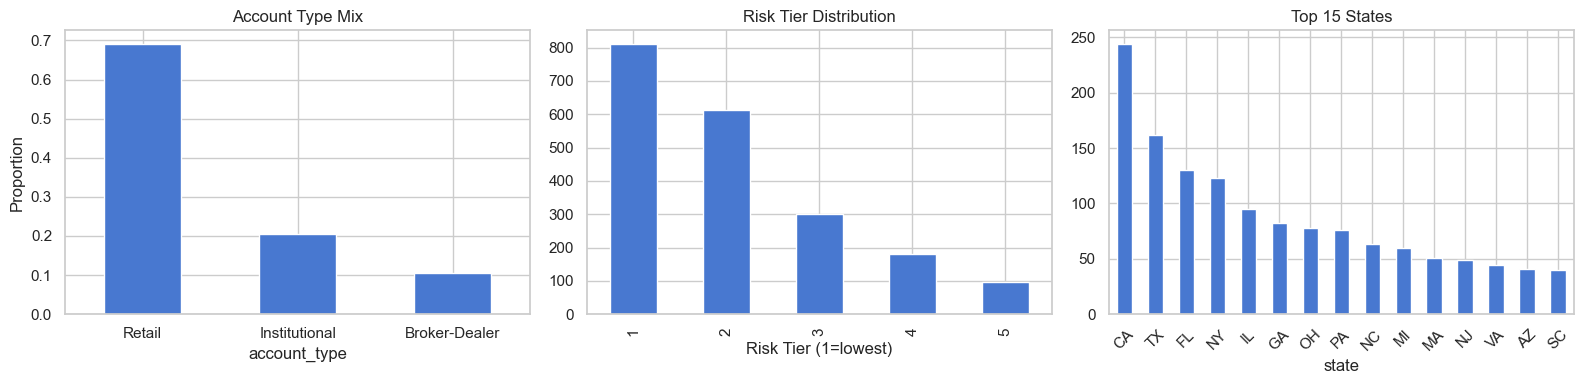

PEP rate: 2.1%  (target: ~2%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

accounts["account_type"].value_counts(normalize=True).plot.bar(ax=axes[0], title="Account Type Mix")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=0)

accounts["risk_tier"].value_counts().sort_index().plot.bar(ax=axes[1], title="Risk Tier Distribution")
axes[1].set_xlabel("Risk Tier (1=lowest)")

accounts["state"].value_counts().head(15).plot.bar(ax=axes[2], title="Top 15 States")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"PEP rate: {accounts['is_pep'].mean():.1%}  (target: ~2%)")

## 5. Income and net worth distributions

Both should follow log-normal distributions. On a log scale they should look roughly normal (bell-shaped). On a linear scale they should have a long right tail.

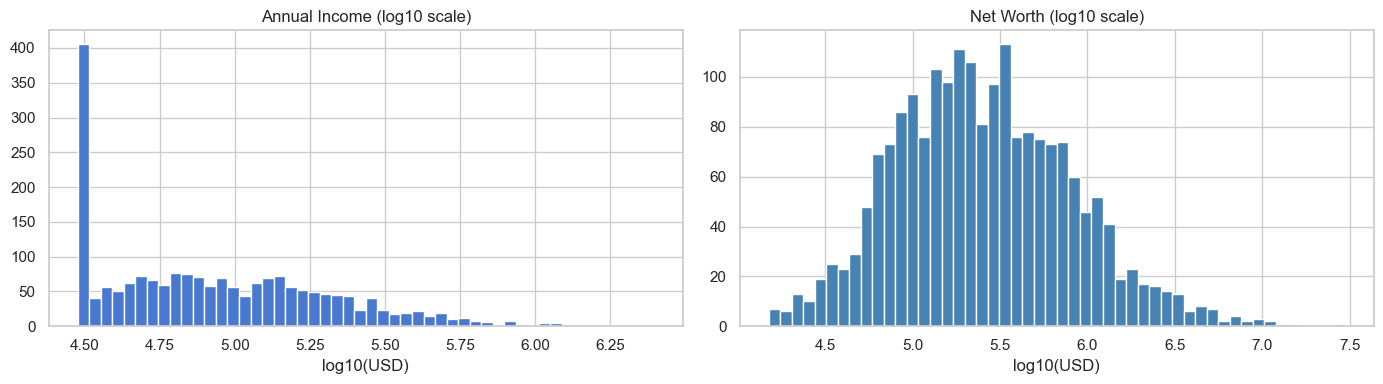

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(np.log10(accounts["annual_income_usd"]), bins=50, edgecolor="white")
axes[0].set_title("Annual Income (log10 scale)")
axes[0].set_xlabel("log10(USD)")

axes[1].hist(np.log10(accounts["net_worth_usd"]), bins=50, edgecolor="white", color="steelblue")
axes[1].set_title("Net Worth (log10 scale)")
axes[1].set_xlabel("log10(USD)")

plt.tight_layout()
plt.show()

## 6. Securities distributions

Checking market cap mix, exchange distribution, and that micro-cap stocks have lower volumes and wider spreads than large-caps (which is how real markets work).

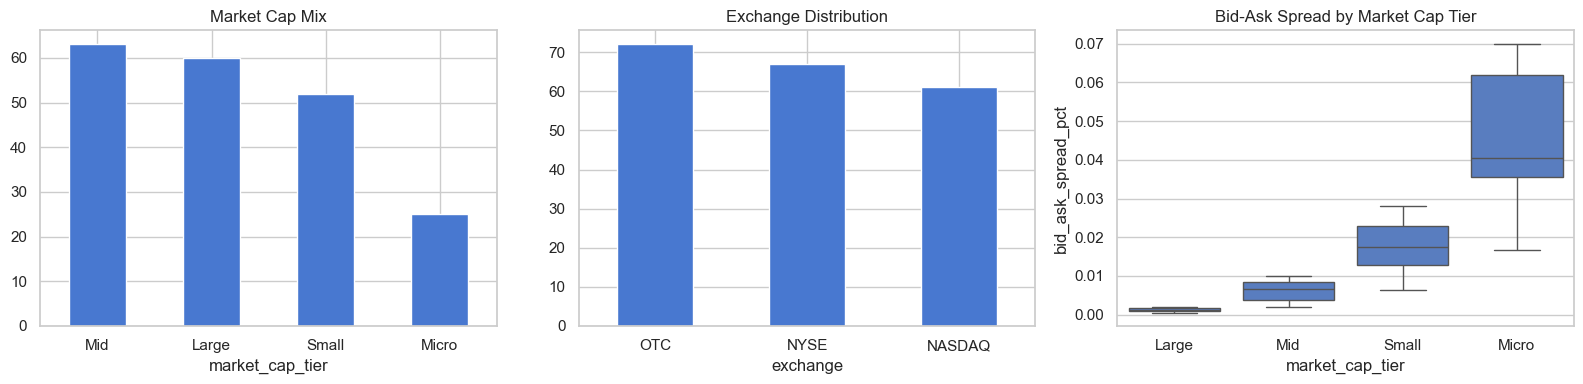

Illiquid stocks: 20.0%  (target: bottom 20%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

securities["market_cap_tier"].value_counts().plot.bar(ax=axes[0], title="Market Cap Mix")
axes[0].tick_params(axis="x", rotation=0)

securities["exchange"].value_counts().plot.bar(ax=axes[1], title="Exchange Distribution")
axes[1].tick_params(axis="x", rotation=0)

# Bid-ask spread by market cap — micro-cap should be widest
cap_order = ["Large", "Mid", "Small", "Micro"]
sns.boxplot(
    data=securities,
    x="market_cap_tier",
    y="bid_ask_spread_pct",
    order=cap_order,
    ax=axes[2]
)
axes[2].set_title("Bid-Ask Spread by Market Cap Tier")

plt.tight_layout()
plt.show()

print(f"Illiquid stocks: {securities['is_illiquid'].mean():.1%}  (target: bottom 20%)")

## 7. Trade volume and value distributions

Trade values should be log-normal. We'll check both log and linear scale, then look at whether `is_round_value` trades are believably distributed.

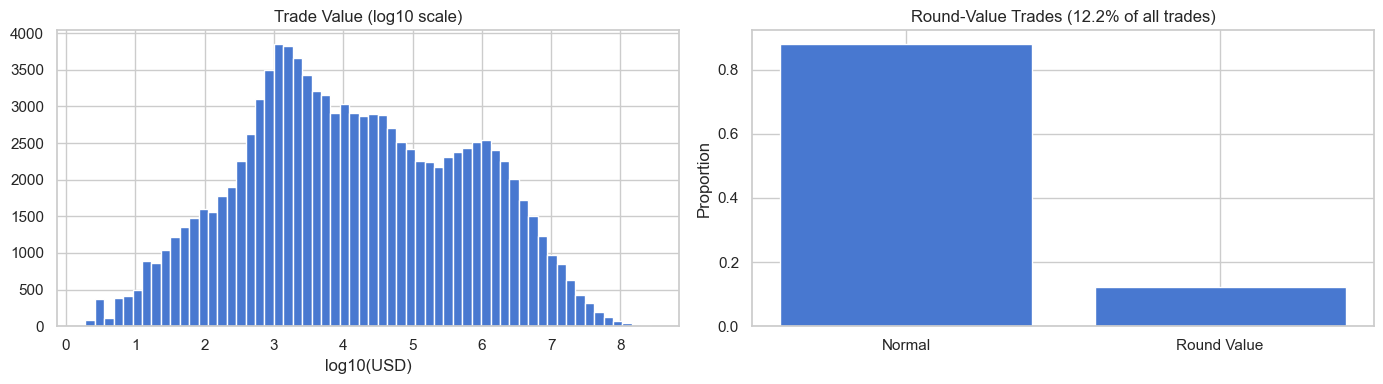

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(np.log10(trades["trade_value_usd"].clip(lower=1)), bins=60, edgecolor="white")
axes[0].set_title("Trade Value (log10 scale)")
axes[0].set_xlabel("log10(USD)")

round_rate = trades["is_round_value"].mean()
axes[1].bar(["Normal", "Round Value"], [1 - round_rate, round_rate])
axes[1].set_title(f"Round-Value Trades ({round_rate:.1%} of all trades)")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

## 8. Trade timing

The majority of trades should cluster in market hours (9:30am–4:00pm ET). Off-hours and weekend trades should be a small minority in the normal population.

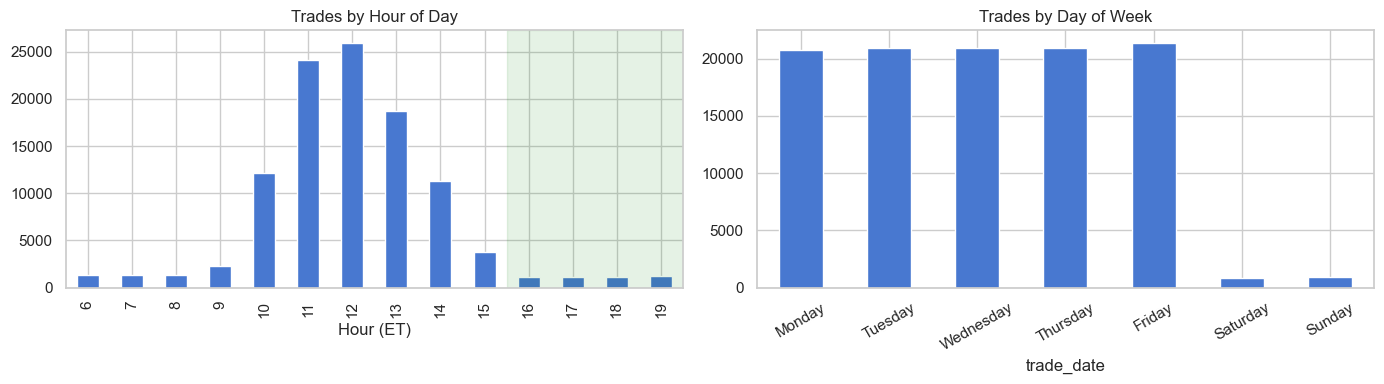

Off-hours trades: 8.8%


In [9]:
trades["trade_hour"] = pd.to_datetime(trades["trade_time"], format="%H:%M:%S").dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trades["trade_hour"].value_counts().sort_index().plot.bar(ax=axes[0], title="Trades by Hour of Day")
axes[0].axvspan(9.5, 16, alpha=0.1, color="green", label="Market hours")
axes[0].set_xlabel("Hour (ET)")

trades["trade_date"].dt.day_name().value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
).plot.bar(ax=axes[1], title="Trades by Day of Week")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"Off-hours trades: {trades['is_off_hours'].mean():.1%}")

## 9. Trade volume per account

How many trades does each account have? We expect high variance — some accounts are very active, most are not. Also look at the injected anomaly accounts: do they stand out in raw trade count?

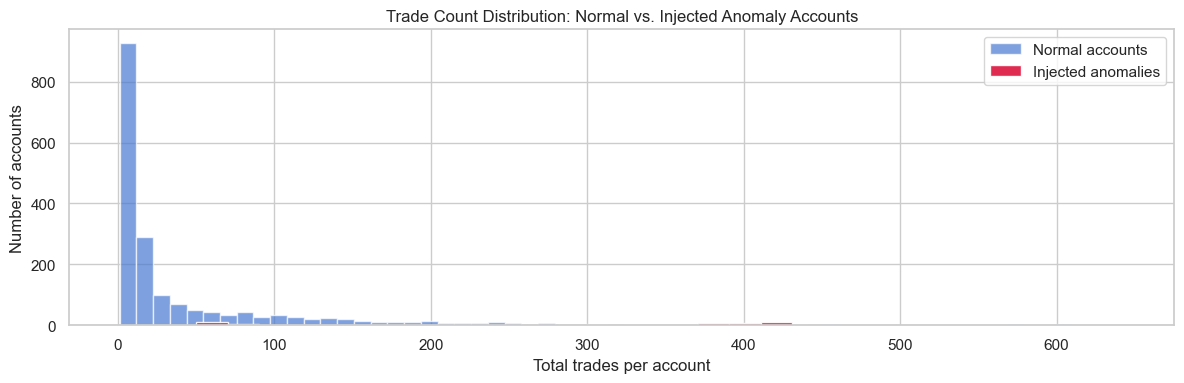

Normal accounts   — median trades: 12, max: 643
Injected accounts — median trades: 379, max: 451


In [10]:
trades_per_account = trades.groupby("account_id").size().reset_index(name="trade_count")
trades_per_account["is_injected"] = trades_per_account["account_id"].isin(injected["account_id"])

fig, ax = plt.subplots(figsize=(12, 4))

normal = trades_per_account[~trades_per_account["is_injected"]]
anomalous = trades_per_account[trades_per_account["is_injected"]]

ax.hist(normal["trade_count"], bins=60, alpha=0.7, label="Normal accounts", edgecolor="white")
ax.hist(anomalous["trade_count"], bins=20, alpha=0.9, label="Injected anomalies", color="crimson", edgecolor="white")
ax.set_xlabel("Total trades per account")
ax.set_ylabel("Number of accounts")
ax.set_title("Trade Count Distribution: Normal vs. Injected Anomaly Accounts")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Normal accounts   — median trades: {normal['trade_count'].median():.0f}, max: {normal['trade_count'].max()}")
print(f"Injected accounts — median trades: {anomalous['trade_count'].median():.0f}, max: {anomalous['trade_count'].max()}")

## 10. Injected anomaly breakdown

How many accounts were injected per pattern, and what do their raw trade stats look like?

In [11]:
print(injected["anomaly_pattern"].value_counts().to_string())
print(f"\nTotal injected accounts: {len(injected)}  ({len(injected)/len(accounts):.1%} of all accounts)")

anomaly_pattern
wash_trading              15
velocity_spike            15
smurfing                  15
illiquid_concentration    15
off_hours_clustering      15

Total injected accounts: 75  (3.8% of all accounts)
